# Pareto observations: exact likelihood and CLT approximation

This notebook visualizes the **precomputed** 24-hour experiment from `saved_path_pareto_comparison`; it does not rerun the filters. The same latent path and the same Pareto observation stream are used throughout.

- **Exact:** Pareto likelihood, step $h_t=1$.
- **Gaussian approximation:** sums of 10 observations, step $h_t=10$, with matched conditional mean and variance.
- **CLT mean:** the same blocks divided by 10, with likelihood parameters scaled accordingly. This is a useful consistency check, but it is not a third independent approximation: scaling an observation and its Gaussian likelihood by the same constant leaves the normalized posterior unchanged.

The experiment and observation model are documented in `pareto_obs.ipynb`; saved config snapshots make this analysis reproducible without depending on the current configs.

In [1]:
from pathlib import Path
import pickle

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})

ROOT = Path.cwd().resolve()
if not (ROOT / 'saved_path_pareto_comparison' / 'comparison.npz').exists():
    ROOT = ROOT.parent
DATA_DIR = ROOT / 'saved_path_pareto_comparison'
assert (DATA_DIR / 'comparison.npz').exists(), 'Run from the repository root or notebooks/'

with np.load(DATA_DIR / 'comparison.npz', allow_pickle=False) as archive:
    data = {name: archive[name] for name in archive.files}

theta, y, jump_times = data['theta'], data['y'], data['t']
obs, obs_sum, obs_mean = data['obs'][:, 0], data['obs_agg'][:, 0], data['obs_mean'][:, 0]
ratio = int(data['ratio'])
t_exact, t_block = data['t_net_exact'], data['t_net_agg']
th_exact, y_exact = data['theta_est_exact'], data['y_est_exact']
th_approx, y_approx = data['theta_est_approx'], data['y_est_approx']
th_clt, y_clt = data['theta_est_clt'], data['y_est_clt']

print(f'Loaded {len(obs):,} Pareto observations and {len(obs_sum):,} blocks of {ratio}.')
print(f'Latent path: {len(theta)} states/segments; horizon {t_block[-1] / 3600:.2f} h.')
print(f'Exact estimates: {th_exact.shape}; block estimates: {th_approx.shape}.')

Loaded 86,380 Pareto observations and 4,319 blocks of 20.
Latent path: 21 states/segments; horizon 23.99 h.
Exact estimates: (86381, 4); block estimates: (4320, 4).


## Integrity checks

The consolidated archive should agree with the three legacy saved-path directories. The checks below also verify that block sums/means came from the exact observation stream and that the two Gaussian formulations are numerically equivalent.

In [2]:
def load_pickle(directory, name):
    with (ROOT / directory / f'{name}.pkl').open('rb') as handle:
        return pickle.load(handle)

legacy = {
    'exact': 'saved_path_pareto_obs_exact',
    'approx': 'saved_path_pareto_obs_approx',
    'clt': 'saved_path_pareto_obs_clt',
}
assert np.allclose(obs_sum, obs.reshape(-1, ratio).sum(axis=1))
assert np.allclose(obs_mean, obs_sum / ratio)
assert np.allclose(load_pickle(legacy['exact'], 'theta_est'), th_exact)
assert np.allclose(load_pickle(legacy['approx'], 'theta_est'), th_approx)
assert np.allclose(load_pickle(legacy['clt'], 'theta_est'), th_clt)

max_theta_equiv = np.max(np.abs(th_approx - th_clt))
max_y_equiv = np.max(np.abs(y_approx - y_clt))
print(f'Block sum vs mean: max |Δ theta| = {max_theta_equiv:.3e}')
print(f'Block sum vs mean: max |Δ Y|     = {max_y_equiv:.3e}')

Block sum vs mean: max |Δ theta| = 1.000e+00
Block sum vs mean: max |Δ Y|     = 2.746e+01


## Does aggregation make the Pareto noise more Gaussian?

For each unit-step observation we subtract its conditional mean $Y_1+Y_2$ and divide by its conditional standard deviation $Y_2/\sqrt{12}$. For a block, conditional means and variances are added before standardization. The reference curve is $N(0,1)$. Central aggregation reduces skewness and the most extreme values, although convergence is slow and a heavy right tail remains visible for Pareto shape $\alpha=2.5$.

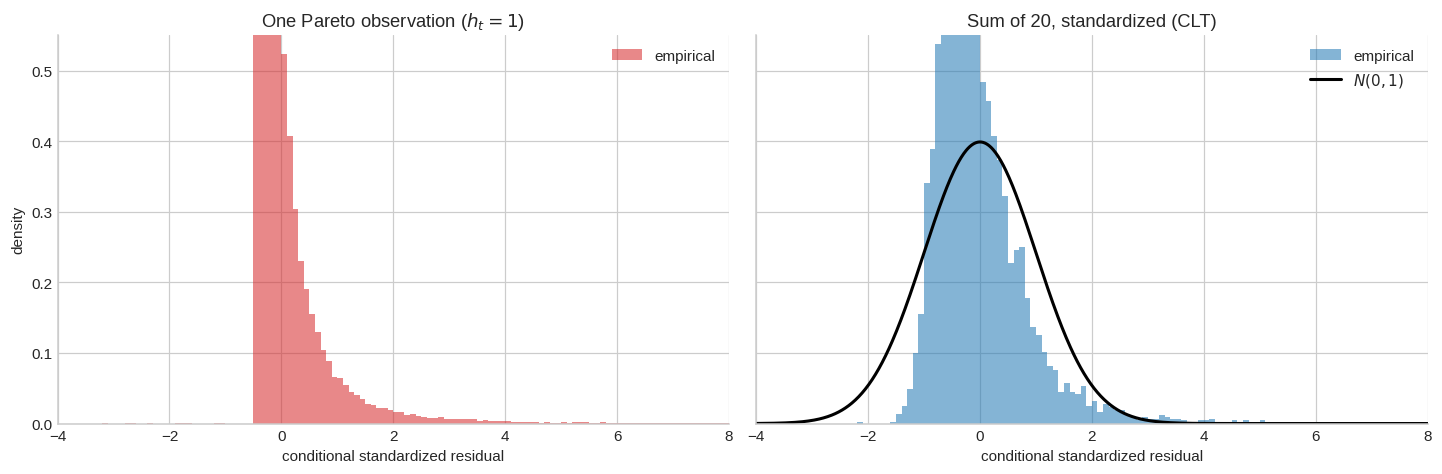

single step : mean= 0.001, std=0.878, skew=12.80, excess kurtosis= 390.6, P(|Z|>3)=1.133%, max=50.76
block of 20 : mean= 0.004, std=0.876, skew= 2.69, excess kurtosis=  15.8, P(|Z|>3)=1.181%, max=9.98


In [3]:
def path_at(grid):
    # theta[k], y[k] apply from the previous jump through jump_times[k].
    idx = np.searchsorted(jump_times, grid, side='left')
    return theta[idx], y[idx]

_, y_step = path_at(t_exact[1:])
mu_step = y_step[:, 0] + y_step[:, 1]
var_step = y_step[:, 1] ** 2 / 12.0
z_step = (obs - mu_step) / np.sqrt(var_step)

mu_block = mu_step.reshape(-1, ratio).sum(axis=1)
var_block = var_step.reshape(-1, ratio).sum(axis=1)
z_block = (obs_sum - mu_block) / np.sqrt(var_block)

x = np.linspace(-4, 8, 800)
normal_pdf = np.exp(-x**2 / 2) / np.sqrt(2 * np.pi)
bins = np.linspace(-4, 8, 121)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True, layout='constrained')
for ax, values, title, color in [
    (axes[0], z_step, 'One Pareto observation ($h_t=1$)', 'tab:red'),
    (axes[1], z_block, f'Sum of {ratio}, standardized (CLT)', 'tab:blue'),
]:
    ax.hist(values, bins=bins, density=True, alpha=.55, color=color, label='empirical')
    ax.set(title=title, xlabel='conditional standardized residual', xlim=(-4, 8), ylim=(0, .55))
axes[1].plot(x, normal_pdf, color='black', lw=2, label='$N(0,1)$')
axes[0].set_ylabel('density')
axes[0].legend()
axes[1].legend()
plt.show()

for label, values in [('single step', z_step), (f'block of {ratio}', z_block)]:
    centered = (values - values.mean()) / values.std()
    skewness = np.mean(centered ** 3)
    excess_kurtosis = np.mean(centered ** 4) - 3
    print(f'{label:12s}: mean={values.mean(): .3f}, std={values.std():.3f}, '
          f'skew={skewness:5.2f}, excess kurtosis={excess_kurtosis:6.1f}, '
          f'P(|Z|>3)={np.mean(np.abs(values)>3):.3%}, max={values.max():.2f}')

## State-probability estimates

The exact estimate is shown on its native one-unit grid; the Gaussian/CLT estimate is on the ten-unit grid. Background shading marks the true latent state. The CLT-mean curve is omitted here because it lies on top of the block-sum curve to numerical precision.

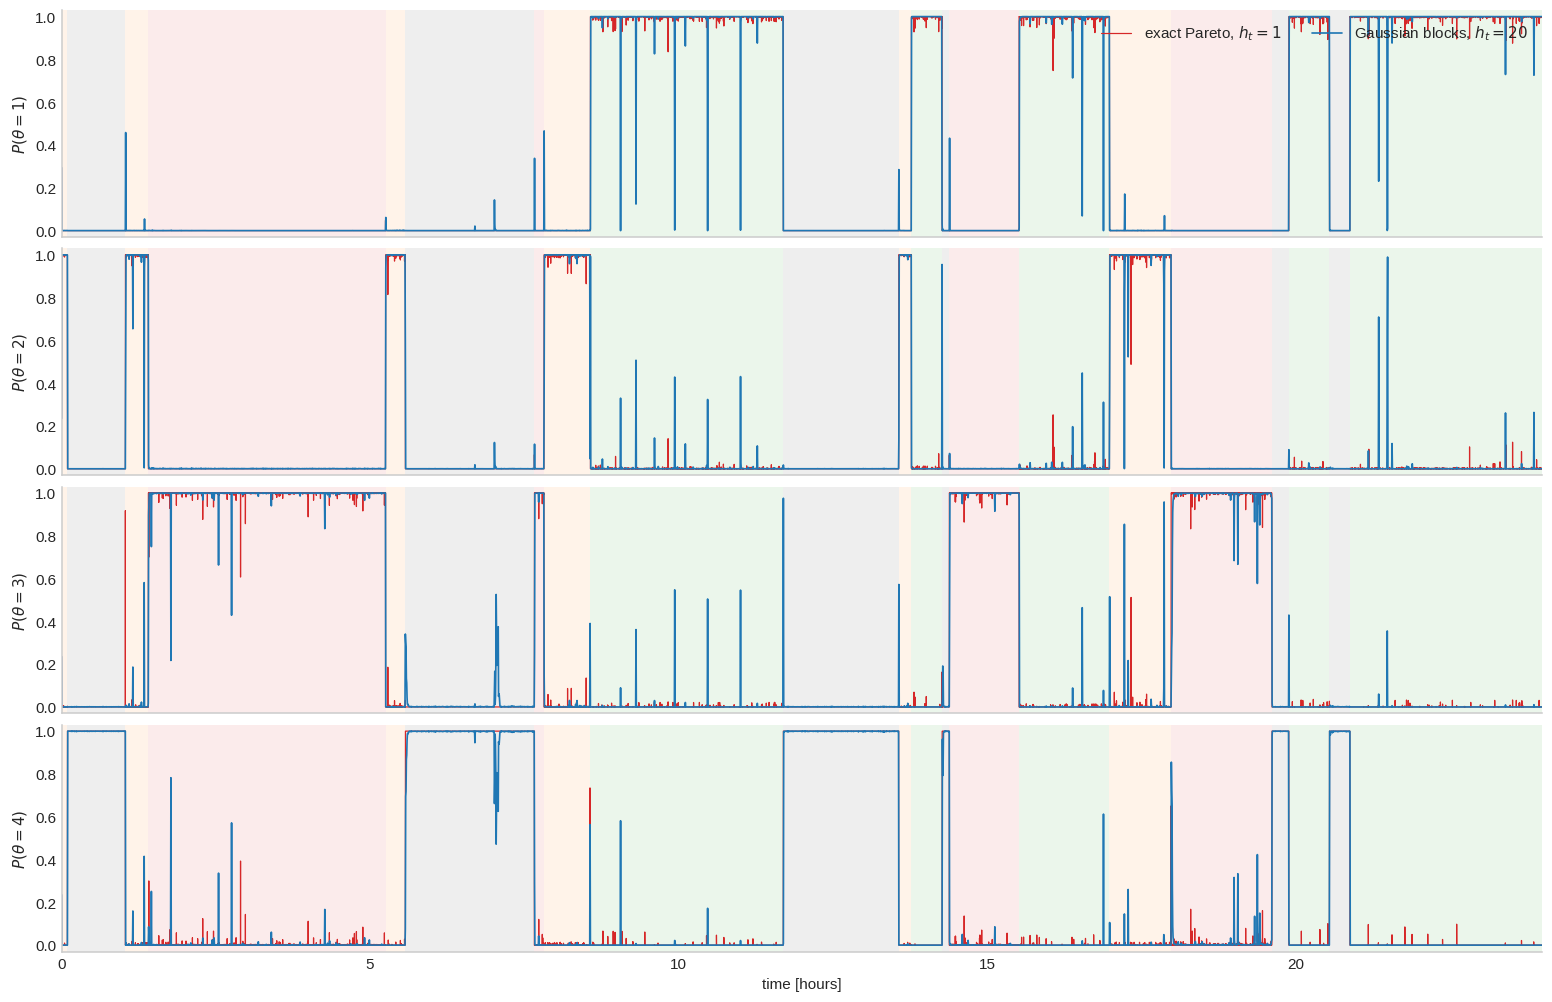

In [9]:
state_colors = ['#2ca02c', '#ff7f0e', '#d62728', '#4d4d4d']
starts = np.r_[0.0, jump_times[:-1]] / 3600
ends = jump_times / 3600

def shade_states(ax):
    for state, left, right in zip(theta, starts, ends):
        ax.axvspan(left, right, color=state_colors[state], alpha=.09, lw=0)

fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True, layout='constrained')
for state, ax in enumerate(axes):
    shade_states(ax)
    ax.plot(t_exact / 3600, th_exact[:, state], color='tab:red', lw=.8, label='exact Pareto, $h_t=1$')
    ax.plot(t_block / 3600, th_approx[:, state], color='tab:blue', lw=1.1, label='Gaussian blocks, $h_t=20$')
    ax.set(ylabel=fr'$P(\theta={state + 1})$', ylim=(-.03, 1.03))
    ax.grid()
axes[0].legend(loc='upper right', ncol=2)
axes[-1].set(xlabel='time [hours]', xlim=(0, t_block[-1] / 3600))
plt.show()

## Continuous-state estimates

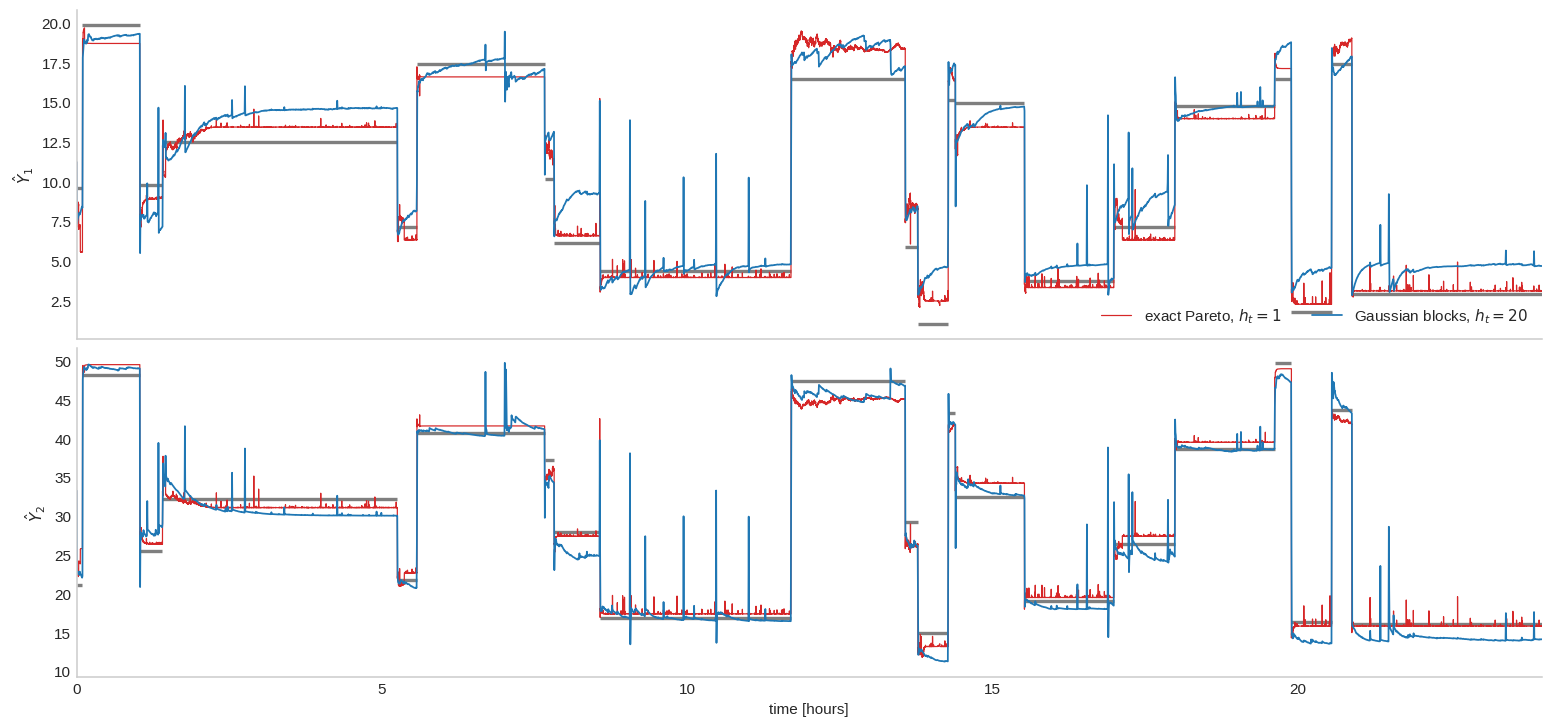

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6.5), sharex=True, layout='constrained')
for component, ax in enumerate(axes):
    for value, left, right in zip(y[:, component], starts, ends):
        ax.hlines(value, left, right, color='black', lw=2.2, alpha=.5)
    ax.plot(t_exact / 3600, y_exact[:, component], color='tab:red', lw=.8, label='exact Pareto, $h_t=1$')
    ax.plot(t_block / 3600, y_approx[:, component], color='tab:blue', lw=1.15, label='Gaussian blocks, $h_t=20$')
    ax.set_ylabel(fr'$\hat Y_{component + 1}$')
    ax.grid()
axes[0].legend(ncol=3, loc='lower right')
axes[-1].set(xlabel='time [hours]', xlim=(0, t_block[-1] / 3600))
plt.show()

## Common-grid accuracy

For a fair comparison, the exact estimate is thinned to the $h_t=10$ grid. State RMSE is over all four one-hot components, matching the experiment summary. The second panel shows cumulative error through time and reveals whether the aggregate result is driven by a short interval.

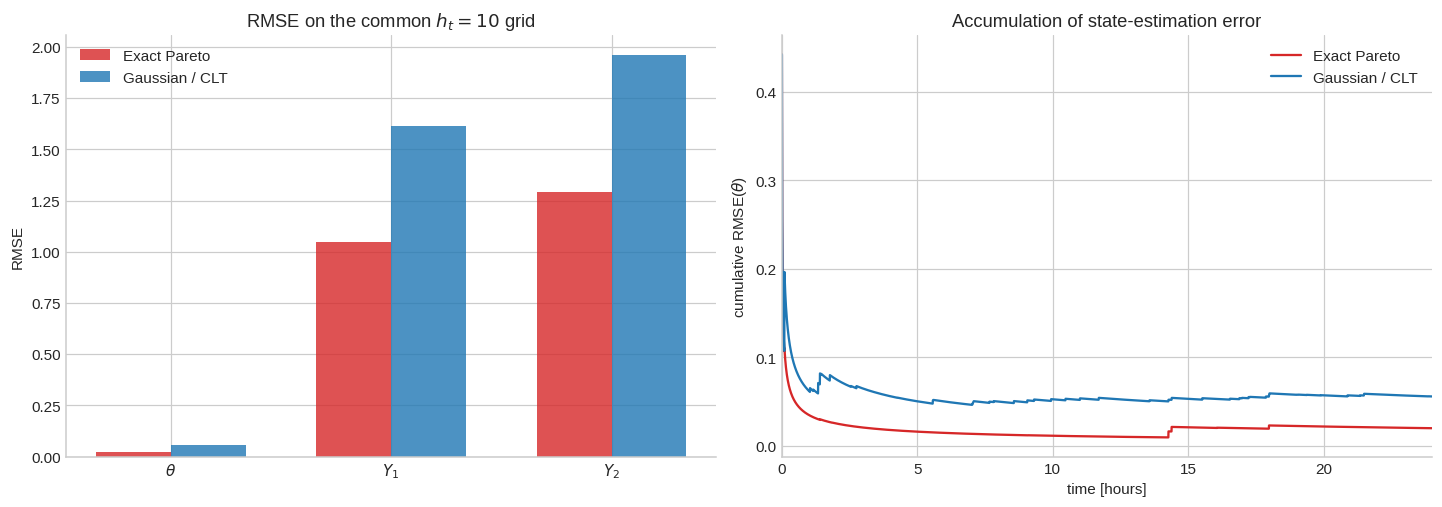

method               RMSE theta    RMSE Y1    RMSE Y2
Exact Pareto             0.0200     1.0485     1.2930
Gaussian / CLT           0.0558     1.6152     1.9588


In [6]:
true_state, true_y = path_at(t_block)
true_onehot = np.eye(th_exact.shape[1])[true_state]
th_exact_block = th_exact[::ratio]
y_exact_block = y_exact[::ratio]
assert th_exact_block.shape == th_approx.shape == true_onehot.shape

methods = {
    'Exact Pareto': (th_exact_block, y_exact_block, 'tab:red'),
    'Gaussian / CLT': (th_approx, y_approx, 'tab:blue'),
}
metrics = {}
for label, (th_hat, y_hat, _) in methods.items():
    metrics[label] = [
        np.sqrt(np.mean((th_hat - true_onehot) ** 2)),
        np.sqrt(np.mean((y_hat[:, 0] - true_y[:, 0]) ** 2)),
        np.sqrt(np.mean((y_hat[:, 1] - true_y[:, 1]) ** 2)),
    ]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), layout='constrained')
positions = np.arange(3)
width = .34
for offset, (label, (_, _, color)) in zip([-.5, .5], methods.items()):
    axes[0].bar(positions + offset * width, metrics[label], width, label=label, color=color, alpha=.8)
axes[0].set(xticks=positions, xticklabels=[r'$\theta$', r'$Y_1$', r'$Y_2$'], ylabel='RMSE', title='RMSE on the common $h_t=10$ grid')
axes[0].legend()

for label, (th_hat, _, color) in methods.items():
    squared = np.mean((th_hat - true_onehot) ** 2, axis=1)
    cumulative = np.sqrt(np.cumsum(squared) / np.arange(1, len(squared) + 1))
    axes[1].plot(t_block / 3600, cumulative, color=color, label=label)
axes[1].set(xlabel='time [hours]', ylabel=r'cumulative RMSE($\theta$)', title='Accumulation of state-estimation error', xlim=(0, t_block[-1] / 3600))
axes[1].legend()
plt.show()

print(f"{'method':18s} {'RMSE theta':>12s} {'RMSE Y1':>10s} {'RMSE Y2':>10s}")
for label, values in metrics.items():
    print(f'{label:18s} {values[0]:12.4f} {values[1]:10.4f} {values[2]:10.4f}')

## Direct exact-versus-CLT discrepancy

These heat maps show where the Gaussian block approximation departs from the exact Pareto filter after aligning both on the block grid. Warm/cool colors denote signed differences, not estimation error against truth.

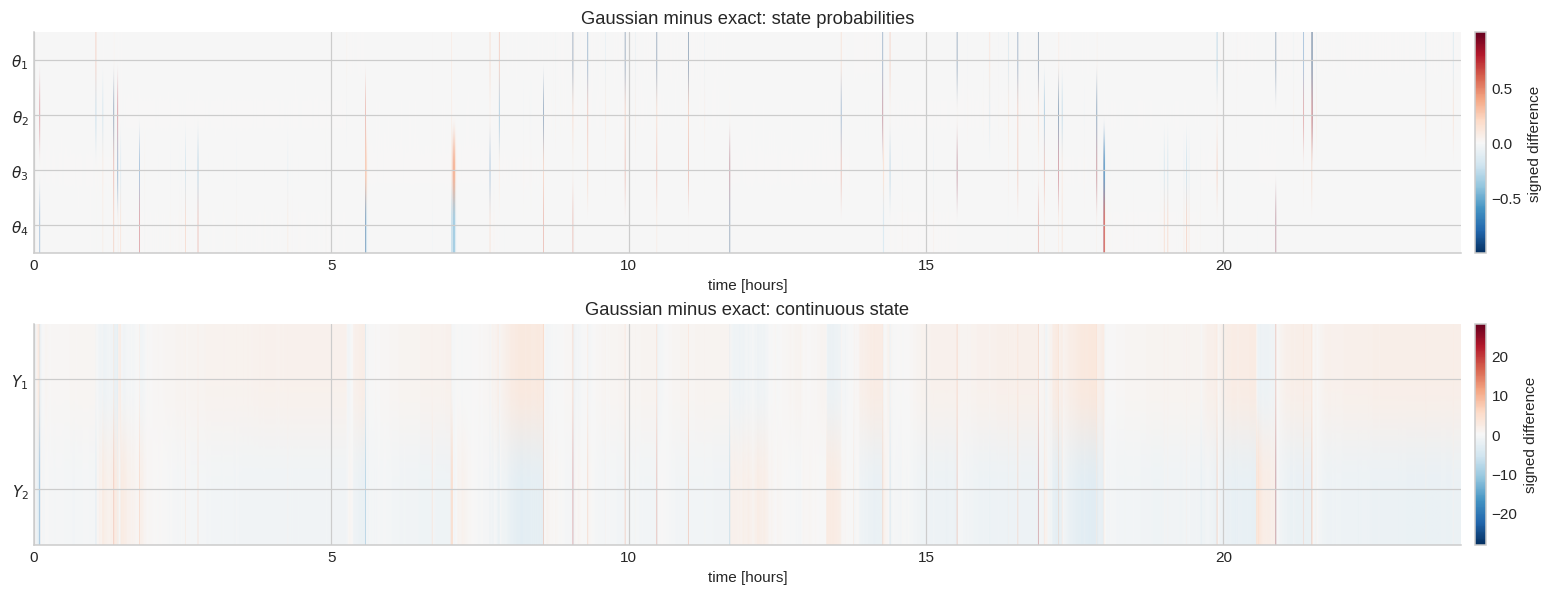

Max |Gaussian − exact| for theta: 0.9999
Max |Gaussian − exact| for Y:     28.2416


In [7]:
theta_diff = (th_approx - th_exact_block).T
y_diff = (y_approx - y_exact_block).T
fig, axes = plt.subplots(2, 1, figsize=(14, 5.3), layout='constrained')
for ax, difference, labels, title in [
    (axes[0], theta_diff, [r'$\theta_1$', r'$\theta_2$', r'$\theta_3$', r'$\theta_4$'], 'Gaussian minus exact: state probabilities'),
    (axes[1], y_diff, [r'$Y_1$', r'$Y_2$'], 'Gaussian minus exact: continuous state'),
]:
    limit = np.max(np.abs(difference))
    image = ax.imshow(difference, aspect='auto', cmap='RdBu_r', vmin=-limit, vmax=limit, extent=[0, t_block[-1] / 3600, difference.shape[0] - .5, -.5])
    ax.set(yticks=np.arange(len(labels)), yticklabels=labels, xlabel='time [hours]', title=title)
    fig.colorbar(image, ax=ax, pad=.01, label='signed difference')
plt.show()

print(f'Max |Gaussian − exact| for theta: {np.max(np.abs(theta_diff)):.4f}')
print(f'Max |Gaussian − exact| for Y:     {np.max(np.abs(y_diff)):.4f}')

## Takeaways

1. Aggregating ten heavy-tailed observations makes the standardized central distribution more Gaussian, which is the CLT mechanism used by the approximation.
2. Sum-block and mean-block filters are identical up to floating-point rounding; they should be interpreted as one Gaussian approximation.
3. On this stored trajectory the exact Pareto likelihood has materially lower RMSE for both the discrete and continuous latent states. Aggregation improves Gaussianity but discards nine out of ten update times and still cannot reproduce the Pareto tail exactly.